# 🧠 Interprétabilité Mécaniste des LLMs
## Appliquée à GPT-2 Small — Les 3 Outils Fondamentaux

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com)

> Ce notebook est un tutoriel complet d'interprétabilité mécaniste appliquée à **GPT-2 Small**.
> Il implémente les 3 outils fondamentaux pour comprendre ce qui se passe **à l'intérieur** d'un LLM.

---

## 🎯 Objectif

Les LLMs sont des **boîtes noires** : on voit ce qu'ils reçoivent et ce qu'ils produisent, mais pas ce qui se passe à l'intérieur. Ce notebook ouvre cette boîte avec 3 outils :

| Outil | Question | Section |
|-------|---------|--------|
| **Classifier Probes** | Où est encodée une information dans les couches ? | Section 2 |
| **Activation Patching** | Quel composant est causalement responsable d'un comportement ? | Section 3 |
| **Sparse Auto-Encoders** | Comment démêler la polysémantie des neurones ? | Section 4 |

---

## 🏗️ Pourquoi GPT-2 Small ?

```
GPT-2 Small :
  → 12 couches Transformer
  → 12 attention heads par couche
  → 768 dimensions (vecteur par token)
  → 117M paramètres
  → Taille idéale : analysable sans GPU puissant
  → Bien documenté dans la littérature de mech interp
```

## 🗂️ Table des matières

- [Section 0 — Imports et configuration](#section-0)
- [Section 1 — Chargement de GPT-2 et exploration](#section-1)
- [Section 2 — Classifier Probes](#section-2)
- [Section 3 — Activation Patching](#section-3)
- [Section 4 — Sparse Auto-Encoders (SAEs)](#section-4)
- [Section 5 — Synthèse et limites](#section-5)

---
<a id='section-0'></a>
## Section 0 — Imports et Configuration

### Bibliothèques utilisées

- **transformers** : charger GPT-2 et ses tokenizer
- **transformer_lens** : bibliothèque spécialisée pour l'interprétabilité des Transformers (Neel Nanda, DeepMind). Elle expose facilement les activations internes, les attention heads, etc.
- **sklearn** : entraîner les Classifier Probes (régression logistique)
- **torch** : calculs tensoriels
- **matplotlib / seaborn** : visualisations

In [1]:
# Installation des dépendances
!pip install transformer_lens transformers torch scikit-learn matplotlib seaborn numpy tqdm --quiet
print('✅ Installation terminée')

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 29.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.4/56.4 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 85.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 821.0/821.0 MB 842.2 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 36.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 116.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.7/897.7 kB 59.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.0/571.0 MB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.2/200.2 MB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 75.7 MB/s eta 0:00:00
   ━━━━━━━━

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# TransformerLens : outil principal pour mech interp sur GPT-2
import transformer_lens
from transformer_lens import HookedTransformer, utils

# Sklearn pour les Classifier Probes
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

# Configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.set_grad_enabled(False)  # Pas besoin de gradients pour l'analyse

print(f'✅ PyTorch version : {torch.__version__}')
print(f'✅ Device : {device}')

# Style des plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

✅ PyTorch version : 2.7.1+cu126
✅ Device : cuda


---
<a id='section-1'></a>
## Section 1 — Chargement de GPT-2 et Exploration

### Architecture de GPT-2 Small

GPT-2 est un **Transformer décodeur** entraîné sur la prédiction du prochain token.

```
Texte d'entrée : "The Eiffel Tower is located in"
         ↓
Tokenisation : [464, 33671, 8598, 318, 5140, 287]
         ↓
Embedding : chaque token → vecteur de 768 dimensions
         ↓
Bloc Transformer 1 :
  ├── LayerNorm
  ├── Multi-Head Attention (12 heads × 64 dims)
  ├── Résidu : x = x + Attention(x)
  ├── LayerNorm
  └── MLP Feed-Forward (768 → 3072 → 768)
         ↓
  ... × 12 blocs ...
         ↓
LayerNorm final
         ↓
Unembed : vecteur 768 → probabilités sur 50257 tokens
         ↓
Prédiction : "Paris" (token le plus probable)
```

### TransformerLens

TransformerLens est une bibliothèque créée par **Neel Nanda** (DeepMind) spécialement pour l'interprétabilité mécaniste. Elle permet :
- D'accéder aux **activations internes** à n'importe quelle couche
- D'utiliser des **hooks** pour intercepter et modifier les activations
- D'analyser les **attention heads** individuellement
- De faire du **patching** facilement

In [4]:
# ─────────────────────────────────────────────────────────────────
# Chargement de GPT-2 Small via TransformerLens
# ─────────────────────────────────────────────────────────────────

print('Chargement de GPT-2 Small...')
model = HookedTransformer.from_pretrained('gpt2', device=device)
model.eval()

print()
print('=' * 55)
print('ARCHITECTURE GPT-2 SMALL')
print('=' * 55)
print(f'  Nombre de couches         : {model.cfg.n_layers}')
print(f'  Nombre d\'attention heads  : {model.cfg.n_heads}')
print(f'  Dimension des vecteurs    : {model.cfg.d_model}')
print(f'  Dimension MLP             : {model.cfg.d_mlp}')
print(f'  Taille vocabulaire        : {model.cfg.d_vocab}')
print(f'  Contexte maximum          : {model.cfg.n_ctx} tokens')
print()

# Test rapide
test_prompt = 'The Eiffel Tower is located in'
test_tokens = model.to_tokens(test_prompt)
test_logits = model(test_tokens)
next_token_id = test_logits[0, -1, :].argmax().item()
next_token = model.to_string([next_token_id])

print(f'Test de prédiction :')
print(f'  Prompt : "{test_prompt}"')
print(f'  Prédiction : "{next_token.strip()}"')
print()
print('✅ GPT-2 Small chargé et fonctionnel')

Chargement de GPT-2 Small...


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Loaded pretrained model gpt2 into HookedTransformer

ARCHITECTURE GPT-2 SMALL
  Nombre de couches         : 12
  Nombre d'attention heads  : 12
  Dimension des vecteurs    : 768
  Dimension MLP             : 3072
  Taille vocabulaire        : 50257
  Contexte maximum          : 1024 tokens

Test de prédiction :
  Prompt : "The Eiffel Tower is located in"
  Prédiction : "the"

✅ GPT-2 Small chargé et fonctionnel


In [5]:
# ─────────────────────────────────────────────────────────────────
# Explorer les activations internes avec run_with_cache
# ─────────────────────────────────────────────────────────────────

print('Exploration des activations internes de GPT-2...')
print()

# run_with_cache exécute le modèle et sauvegarde TOUTES les activations
prompt = 'The Eiffel Tower is located in Paris, the capital of'
tokens = model.to_tokens(prompt)
token_strings = model.to_str_tokens(prompt)

logits, cache = model.run_with_cache(tokens)

print(f'Prompt : "{prompt}"')
print(f'Tokens : {token_strings}')
print()
print('Activations disponibles dans le cache :')
print()

# Lister quelques clés importantes
important_keys = [
    'embed',                    # Embeddings d'entrée
    'blocks.0.attn.hook_q',     # Queries de l'attention (couche 0)
    'blocks.0.attn.hook_k',     # Keys de l'attention (couche 0)
    'blocks.0.attn.hook_v',     # Values de l'attention (couche 0)
    'blocks.0.attn.hook_attn_scores',  # Scores d'attention
    'blocks.0.hook_resid_post', # Résidu après couche 0
    'blocks.6.hook_resid_post', # Résidu après couche 6
    'blocks.11.hook_resid_post',# Résidu après couche 11
]

for key in important_keys:
    if key in cache:
        shape = cache[key].shape
        print(f'  {key:<45} → shape : {shape}')

print()
print('Interprétation des dimensions :')
print('  (batch, seq_len, d_model) = (1, n_tokens, 768)')
print('  (batch, seq_len, n_heads, d_head) = (1, n_tokens, 12, 64)')

Exploration des activations internes de GPT-2...

Prompt : "The Eiffel Tower is located in Paris, the capital of"
Tokens : ['<|endoftext|>', 'The', ' E', 'iff', 'el', ' Tower', ' is', ' located', ' in', ' Paris', ',', ' the', ' capital', ' of']

Activations disponibles dans le cache :

  blocks.0.attn.hook_q                          → shape : torch.Size([1, 14, 12, 64])
  blocks.0.attn.hook_k                          → shape : torch.Size([1, 14, 12, 64])
  blocks.0.attn.hook_v                          → shape : torch.Size([1, 14, 12, 64])
  blocks.0.attn.hook_attn_scores                → shape : torch.Size([1, 12, 14, 14])
  blocks.0.hook_resid_post                      → shape : torch.Size([1, 14, 768])
  blocks.6.hook_resid_post                      → shape : torch.Size([1, 14, 768])
  blocks.11.hook_resid_post                     → shape : torch.Size([1, 14, 768])

Interprétation des dimensions :
  (batch, seq_len, d_model) = (1, n_tokens, 768)
  (batch, seq_len, n_heads, d_head) = 

---
<a id='section-2'></a>
## Section 2 — Classifier Probes

### 📌 Rappel du principe

Un **Classifier Probe** est un classifieur simple (régression logistique) entraîné sur les vecteurs internes du LLM pour vérifier si une information est encodée dans une couche donnée.

```
Intuition :
─────────────────────────────────────────────────────────
Si la couche N encode l'information X
→ le vecteur de cette couche doit permettre de prédire X
→ un classifieur simple y arrive facilement
→ précision élevée = information présente dans cette couche

Si la couche N n'encode PAS X
→ le vecteur ne contient pas l'info
→ le classifieur ne peut pas distinguer
→ précision proche du hasard (50%)
```

### 🔬 Expérience : Détection NOM vs VERBE

Nous allons sonder à quelle couche de GPT-2 l'information grammaticale **NOM vs VERBE** est encodée pour des mots ambigus (mots qui peuvent être les deux selon le contexte).

**Exemples de mots ambigus :**
- *"run"* : "I run every day" (VERBE) vs "a short run" (NOM)
- *"light"* : "she turned on the light" (NOM) vs "light the candle" (VERBE)
- *"water"* : "drink some water" (NOM) vs "water the plants" (VERBE)

In [9]:
extra_data = [
    # POSITIF
    ("The surgery was a complete success", 1),
    ("She was finally debt free", 1),
    ("The hostages were released unharmed", 1),
    ("The missing child was found safe", 1),
    ("The strike ended with a fair agreement", 1),
    ("The river returned to normal levels", 1),
    ("The court overturned the wrongful conviction", 1),
    ("The team qualified for the finals", 1),
    ("The treatment put the disease into remission", 1),
    ("The plane landed safely despite the storm", 1),
    ("The company avoided bankruptcy", 1),
    ("She graduated at the top of her class", 1),
    ("The wildfire was finally brought under control", 1),
    ("The trapped miners were rescued after three days", 1),
    ("The peace talks produced a lasting agreement", 1),
    ("The audit found no irregularities", 1),
    ("His memory slowly returned after the accident", 1),
    ("The contaminated water supply was cleared", 1),
    ("The endangered bird was removed from the list", 1),
    ("She won the case after a long legal battle", 1),
    ("The factory reopened after the safety violations were fixed", 1),
    ("The patient was discharged after a full recovery", 1),
    ("The loan was repaid ahead of schedule", 1),
    ("The power grid was restored after the attack", 1),
    ("The stranded travelers finally reached their destination", 1),
    ("The flooding receded before reaching the homes", 1),
    ("The investigation found no evidence of wrongdoing", 1),
    ("The athlete recovered in time for the championship", 1),
    ("The new treatment eliminated the symptoms entirely", 1),
    ("The children were evacuated safely before the collapse", 1),

    # NÉGATIF
    ("The surgery revealed complications no one had anticipated", 0),
    ("She accumulated more debt despite her efforts", 0),
    ("The hostages remained in captivity for months", 0),
    ("The search for the missing child was called off", 0),
    ("The strike dragged on without resolution", 0),
    ("The river burst its banks for the second time", 0),
    ("The wrongful conviction was upheld on appeal", 0),
    ("The team was eliminated in the first round", 0),
    ("The disease progressed despite treatment", 0),
    ("The plane made an emergency landing with injuries reported", 0),
    ("The company filed for bankruptcy protection", 0),
    ("She dropped out before completing her degree", 0),
    ("The wildfire consumed thousands of acres overnight", 0),
    ("The miners were not reached in time", 0),
    ("The peace talks collapsed after two sessions", 0),
    ("The audit uncovered years of financial fraud", 0),
    ("He showed no signs of recovery after the accident", 0),
    ("The water supply remained unsafe for months", 0),
    ("The endangered species was declared extinct", 0),
    ("She lost the case after years of litigation", 0),
    ("The factory was permanently shut down after violations", 0),
    ("The patient was readmitted within a week of discharge", 0),
    ("The loan defaulted after missed payments", 0),
    ("The power grid remained offline after the attack", 0),
    ("The travelers were stranded for a second week", 0),
    ("The flooding destroyed dozens of homes", 0),
    ("The investigation led to multiple indictments", 0),
    ("The athlete's injury ended his season permanently", 0),
    ("The symptoms returned within weeks of stopping treatment", 0),
    ("The building collapsed before everyone could be evacuated", 0),
]

probe_data_raw = probe_data_raw + extra_data
probe_data = [(s, '[LAST]', -1, l) for s, l in probe_data_raw]
print(f"Dataset total : {len(probe_data_raw)} exemples")

Dataset total : 160 exemples


In [10]:
# ─────────────────────────────────────────────────────────────────
# Extraction des vecteurs d'activation couche par couche
# ─────────────────────────────────────────────────────────────────
def extract_residual_stream(model, sentence, target_word_idx):
    tokens = model.to_tokens(sentence)
    _, cache = model.run_with_cache(tokens)
    activations = {}

    # Embedding : moyenne sur tous les tokens
    embed = cache['hook_embed'][0, :, :].mean(dim=0).cpu().numpy()
    activations['embed'] = embed

    for layer in range(model.cfg.n_layers):
        key = f'blocks.{layer}.hook_resid_post'
        # ✅ mean pooling au lieu du dernier token uniquement
        vec = cache[key][0, :, :].mean(dim=0).cpu().numpy()
        activations[f'layer_{layer}'] = vec

    return activations


print('Extraction des activations pour tous les exemples du dataset...')
print('(cela prend ~1 minute)')
print()

# Extraire les vecteurs pour chaque exemple, à chaque couche
all_layer_names = ['embed'] + [f'layer_{i}' for i in range(model.cfg.n_layers)]
all_activations = {layer: [] for layer in all_layer_names}
all_labels = []

# Dans la boucle d'extraction, remplacer la recherche de token par :
for sentence, target_word, target_pos, label in tqdm(probe_data):
    # target_pos ignoré — on prend le mean pooling
    acts = extract_residual_stream(model, sentence, target_pos)
    for layer_name in all_layer_names:
        all_activations[layer_name].append(acts[layer_name])
    all_labels.append(label)

# Convertir en arrays numpy
for layer_name in all_layer_names:
    all_activations[layer_name] = np.array(all_activations[layer_name])

all_labels = np.array(all_labels)

print(f'✅ Extraction terminée')
print(f'   Shape des activations par couche : {all_activations["layer_0"].shape}')
print(f'   = ({len(probe_data)} exemples, 768 dimensions)')

Extraction des activations pour tous les exemples du dataset...
(cela prend ~1 minute)



100%|██████████| 160/160 [01:35<00:00,  1.67it/s]

✅ Extraction terminée
   Shape des activations par couche : (160, 768)
   = (160 exemples, 768 dimensions)


In [13]:
from sklearn.model_selection import StratifiedKFold
import numpy as np
from sklearn.svm import SVC

print('=' * 55)
print('ENTRAÎNEMENT DES CLASSIFIER PROBES')
print('=' * 55)
print()

probe_accuracies = {}
N_SPLITS = 5  # cross-validation 5 folds

for layer_name in all_layer_names:
    X = all_activations[layer_name]
    y = all_labels

    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
    fold_accs = []

    for train_idx, test_idx in skf.split(X, y):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        # Normalisation
        scaler = StandardScaler()
        X_train_sc = scaler.fit_transform(X_train)
        X_test_sc  = scaler.transform(X_test)

        # ✅ PCA supprimé — on travaille directement sur les 768 dims
        # ✅ C=1.0 au lieu de 0.01 — régularisation standard


    # Remplacer LogisticRegression par :
    clf = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
    clf.fit(X_train_sc, y_train)
    fold_accs.append(accuracy_score(y_test, clf.predict(X_test_sc)))
    acc = np.mean(fold_accs)
    std = np.std(fold_accs)
    probe_accuracies[layer_name] = (acc, std)

    layer_display = layer_name.replace('layer_', 'Couche ').replace('embed', 'Embed ')
    bar = '█' * int(acc * 30)
    print(f'  {layer_display:<10} | {bar:<30} | {acc:.1%} ')

best_layer = max(probe_accuracies, key=lambda k: probe_accuracies[k][0])
best_acc, best_std = probe_accuracies[best_layer]
print(f'\n  → Meilleure couche : {best_layer} (précision : {best_acc:.1%})')

ENTRAÎNEMENT DES CLASSIFIER PROBES

  Embed      | ████████████████               | 56.2% 
  Couche 0   | ██████████████████             | 62.5% 
  Couche 1   | ████████████████               | 56.2% 
  Couche 2   | █████████████████              | 59.4% 
  Couche 3   | ████████████████               | 56.2% 
  Couche 4   | █████████████████              | 59.4% 
  Couche 5   | ██████████████████████         | 75.0% 
  Couche 6   | █████████████████████          | 71.9% 
  Couche 7   | ████████████████████           | 68.8% 
  Couche 8   | ████████████████████           | 68.8% 
  Couche 9   | ████████████████████           | 68.8% 
  Couche 10  | ███████████████████            | 65.6% 
  Couche 11  | ████████████████               | 56.2% 

  → Meilleure couche : layer_5 (précision : 75.0%)


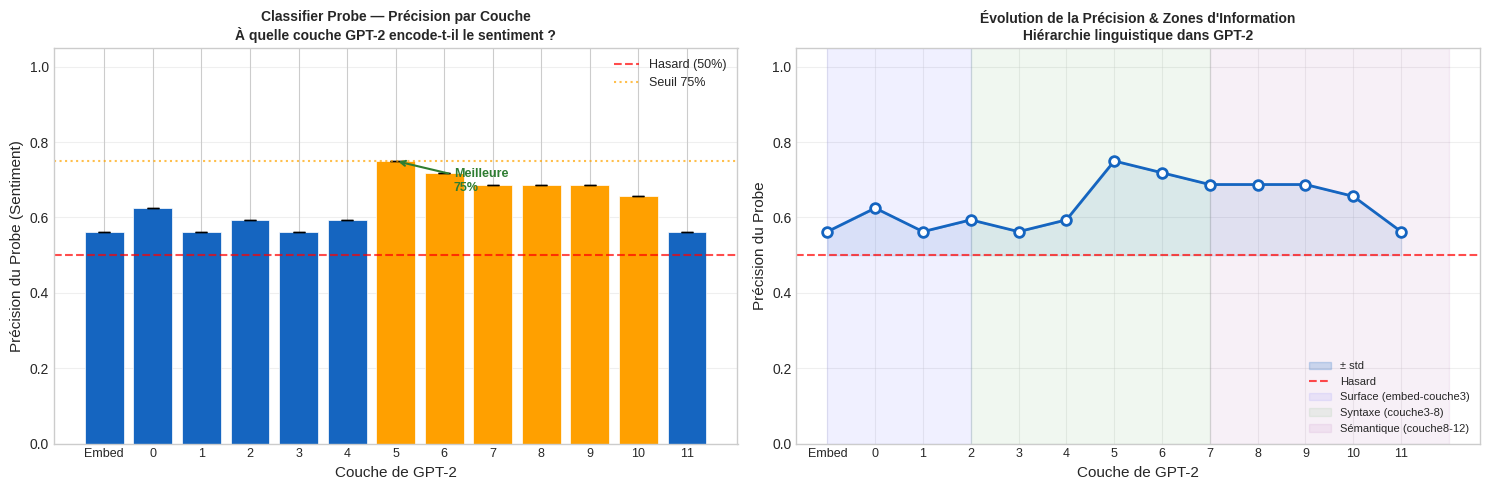

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ✅ Extraire acc et std depuis les tuples (acc, std)
layers_list = list(probe_accuracies.keys())
accs_list   = [probe_accuracies[l][0] for l in layers_list]
stds_list   = [probe_accuracies[l][1] for l in layers_list]
x_pos       = range(len(layers_list))
x_labels    = ['Embed'] + [str(i) for i in range(model.cfg.n_layers)]

# ─── Graphe 1 : Précision par couche avec barres d'erreur ───
colors_bar = ['#1565C0' if a < 0.65 else ('#FFA000' if a < 0.80 else '#2E7D32') for a in accs_list]
bars = axes[0].bar(x_pos, accs_list, color=colors_bar, edgecolor='white', linewidth=0.5)

# ✅ Barres d'erreur (std)
axes[0].errorbar(x_pos, accs_list, yerr=stds_list,
                 fmt='none', color='black', capsize=4, linewidth=1.5)

axes[0].axhline(y=0.5, color='red',    linestyle='--', linewidth=1.5, label='Hasard (50%)', alpha=0.7)
axes[0].axhline(y=0.75, color='orange', linestyle=':',  linewidth=1.5, label='Seuil 75%',   alpha=0.7)

# Annotation de la meilleure couche
best_idx = layers_list.index(best_layer)
axes[0].annotate(
    f'Meilleure\n{best_acc:.0%}',
    xy=(best_idx, best_acc),
    xytext=(best_idx + 1.2, best_acc - 0.08),
    fontsize=9, color='#2E7D32', fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='#2E7D32', lw=1.5)
)

axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(x_labels, fontsize=9)
axes[0].set_xlabel('Couche de GPT-2', fontsize=11)
axes[0].set_ylabel('Précision du Probe (Sentiment)', fontsize=11)
axes[0].set_title('Classifier Probe — Précision par Couche\nÀ quelle couche GPT-2 encode-t-il le sentiment ?',
                   fontsize=10, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].set_ylim(0, 1.05)
axes[0].grid(True, alpha=0.3, axis='y')

# ─── Graphe 2 : Évolution avec zone d'incertitude ───
axes[1].plot(x_pos, accs_list, 'o-', color='#1565C0', linewidth=2,
             markersize=7, markerfacecolor='white', markeredgewidth=2)

# ✅ Zone d'incertitude (mean ± std)
accs_arr = np.array(accs_list)
stds_arr = np.array(stds_list)
axes[1].fill_between(x_pos, accs_arr - stds_arr, accs_arr + stds_arr,
                     alpha=0.2, color='#1565C0', label='± std')
axes[1].fill_between(x_pos, 0.5, accs_list, alpha=0.1, color='#1565C0')

axes[1].axhline(y=0.5, color='red', linestyle='--', linewidth=1.5, label='Hasard', alpha=0.7)

# Zones linguistiques
axes[1].axvspan(0, 3,  alpha=0.06, color='blue',   label='Surface (embed-couche3)')
axes[1].axvspan(3, 8,  alpha=0.06, color='green',  label='Syntaxe (couche3-8)')
axes[1].axvspan(8, 13, alpha=0.06, color='purple', label='Sémantique (couche8-12)')

axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(x_labels, fontsize=9)
axes[1].set_xlabel('Couche de GPT-2', fontsize=11)
axes[1].set_ylabel('Précision du Probe', fontsize=11)
axes[1].set_title("Évolution de la Précision & Zones d'Information\nHiérarchie linguistique dans GPT-2",
                   fontsize=10, fontweight='bold')
axes[1].legend(fontsize=8, loc='lower right')
axes[1].set_ylim(0, 1.05)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
<a id='section-3'></a>
## Section 3 — Activation Patching

### 📌 Rappel du principe

L'**Activation Patching** prouve la **causalité** : quel composant du modèle est **réellement responsable** d'une prédiction ?

```
Idée centrale :
─────────────────────────────────────────────────────────
On prend deux phrases minimalement différentes :

  CLEAN     : "...John gave a drink to ___" → prédit "Mary"
  CORRUPTED : "...Mary gave a drink to ___" → prédit "John"

On patche (copie-colle) les activations d'un composant
de CLEAN → CORRUPTED.

Si le patch restaure la prédiction "Mary"
→ ce composant EST causalement responsable

Si le patch ne change rien
→ ce composant n'est PAS le responsable
```

### 🔬 Expérience : Indirect Object Identification (IOI)

Cette tâche a été étudiée en détail par Wang et al. 2022 dans *"Interpretability in the Wild"*.

Le modèle doit identifier l'objet indirect (la personne qui reçoit quelque chose) dans une phrase.

In [16]:
# ─────────────────────────────────────────────────────────────────
# Setup de l'expérience Activation Patching
# ─────────────────────────────────────────────────────────────────

print('=' * 60)
print('ACTIVATION PATCHING — IOI (Indirect Object Identification)')
print('=' * 60)
print()

# Paires minimales (CLEAN / CORRUPTED)
CLEAN_PROMPT     = 'When Mary and John went to the store, John gave a drink to'
CORRUPTED_PROMPT = 'When Mary and John went to the store, Mary gave a drink to'

# Tokens cibles
CORRECT_TOKEN   = ' Mary'   # Réponse attendue pour CLEAN
INCORRECT_TOKEN = ' John'   # Réponse du modèle sur CORRUPTED

clean_tokens     = model.to_tokens(CLEAN_PROMPT)
corrupted_tokens = model.to_tokens(CORRUPTED_PROMPT)

correct_id   = model.to_single_token(CORRECT_TOKEN)
incorrect_id = model.to_single_token(INCORRECT_TOKEN)

print(f'Phrase CLEAN     : "{CLEAN_PROMPT}"')
print(f'Phrase CORRUPTED : "{CORRUPTED_PROMPT}"')
print()

# Vérifier les prédictions initiales
clean_logits,     clean_cache     = model.run_with_cache(clean_tokens)
corrupted_logits, corrupted_cache = model.run_with_cache(corrupted_tokens)

clean_mary  = clean_logits[0, -1, correct_id].item()
clean_john  = clean_logits[0, -1, incorrect_id].item()
corr_mary   = corrupted_logits[0, -1, correct_id].item()
corr_john   = corrupted_logits[0, -1, incorrect_id].item()

print('Logits sur le dernier token :')
print(f'  Phrase CLEAN     → logit(Mary) = {clean_mary:.3f} | logit(John) = {clean_john:.3f}')
print(f'  Phrase CORRUPTED → logit(Mary) = {corr_mary:.3f} | logit(John) = {corr_john:.3f}')
print()

clean_pred     = model.tokenizer.decode([clean_logits[0, -1, :].argmax().item()])
corrupted_pred = model.tokenizer.decode([corrupted_logits[0, -1, :].argmax().item()])
print(f'  Prédiction CLEAN     : "{clean_pred.strip()}"')
print(f'  Prédiction CORRUPTED : "{corrupted_pred.strip()}"')
print()

# Métrique : log-ratio Mary/John
def logit_diff(logits):
    """Différence de logit Mary - John (métrique principale)."""
    return (logits[0, -1, correct_id] - logits[0, -1, incorrect_id]).item()

clean_ld     = logit_diff(clean_logits)
corrupted_ld = logit_diff(corrupted_logits)

print(f'Métrique logit_diff = logit(Mary) - logit(John) :')
print(f'  CLEAN     : {clean_ld:+.3f}  → Mary favorisée ✅')
print(f'  CORRUPTED : {corrupted_ld:+.3f}  → John favorisé ❌')
print()
print('Objectif du patching : retrouver une logit_diff proche de CLEAN')
print('après avoir patché les activations d\'un composant spécifique.')

ACTIVATION PATCHING — IOI (Indirect Object Identification)

Phrase CLEAN     : "When Mary and John went to the store, John gave a drink to"
Phrase CORRUPTED : "When Mary and John went to the store, Mary gave a drink to"

Logits sur le dernier token :
  Phrase CLEAN     → logit(Mary) = 18.466 | logit(John) = 15.105
  Phrase CORRUPTED → logit(Mary) = 14.967 | logit(John) = 17.446

  Prédiction CLEAN     : "Mary"
  Prédiction CORRUPTED : "John"

Métrique logit_diff = logit(Mary) - logit(John) :
  CLEAN     : +3.362  → Mary favorisée ✅
  CORRUPTED : -2.479  → John favorisé ❌

Objectif du patching : retrouver une logit_diff proche de CLEAN
après avoir patché les activations d'un composant spécifique.


In [17]:
# ─────────────────────────────────────────────────────────────────
# Activation Patching — couche par couche, token par token
# ─────────────────────────────────────────────────────────────────

print('Exécution du patching exhaustif...')
print('Pour chaque (couche, token) : on patche les activations de')
print('CORRUPTED par celles de CLEAN et on mesure l\'effet sur logit_diff.')
print()

n_layers = model.cfg.n_layers
n_tokens = clean_tokens.shape[1]
token_labels = model.to_str_tokens(CLEAN_PROMPT)

# Matrice des résultats : (n_layers, n_tokens)
patch_results = np.zeros((n_layers, n_tokens))

for layer in tqdm(range(n_layers), desc='Couches'):
    for token_pos in range(n_tokens):

        # Valeur de l'activation CLEAN à cette position
        clean_act = clean_cache[f'blocks.{layer}.hook_resid_post'][0, token_pos, :]

        # Hook : remplace l'activation à (layer, token_pos) par celle de CLEAN
        def patch_hook(value, hook, layer=layer, token_pos=token_pos, act=clean_act):
            value[0, token_pos, :] = act
            return value

        hook_name = f'blocks.{layer}.hook_resid_post'

        # Faire tourner CORRUPTED avec le patch
        patched_logits = model.run_with_hooks(
            corrupted_tokens,
            fwd_hooks=[(hook_name, patch_hook)]
        )

        # Mesurer l'effet : normaliser entre 0 (aucun effet) et 1 (effet total)
        patched_ld = logit_diff(patched_logits)
        normalized = (patched_ld - corrupted_ld) / (clean_ld - corrupted_ld)
        patch_results[layer, token_pos] = normalized

print()
print('✅ Patching terminé')
print(f'   Shape de la matrice de résultats : {patch_results.shape}')
print(f'   = ({n_layers} couches × {n_tokens} tokens)')

Exécution du patching exhaustif...
Pour chaque (couche, token) : on patche les activations de
CORRUPTED par celles de CLEAN et on mesure l'effet sur logit_diff.



Couches: 100%|██████████| 12/12 [01:26<00:00,  7.25s/it]


✅ Patching terminé
   Shape de la matrice de résultats : (12, 15)
   = (12 couches × 15 tokens)


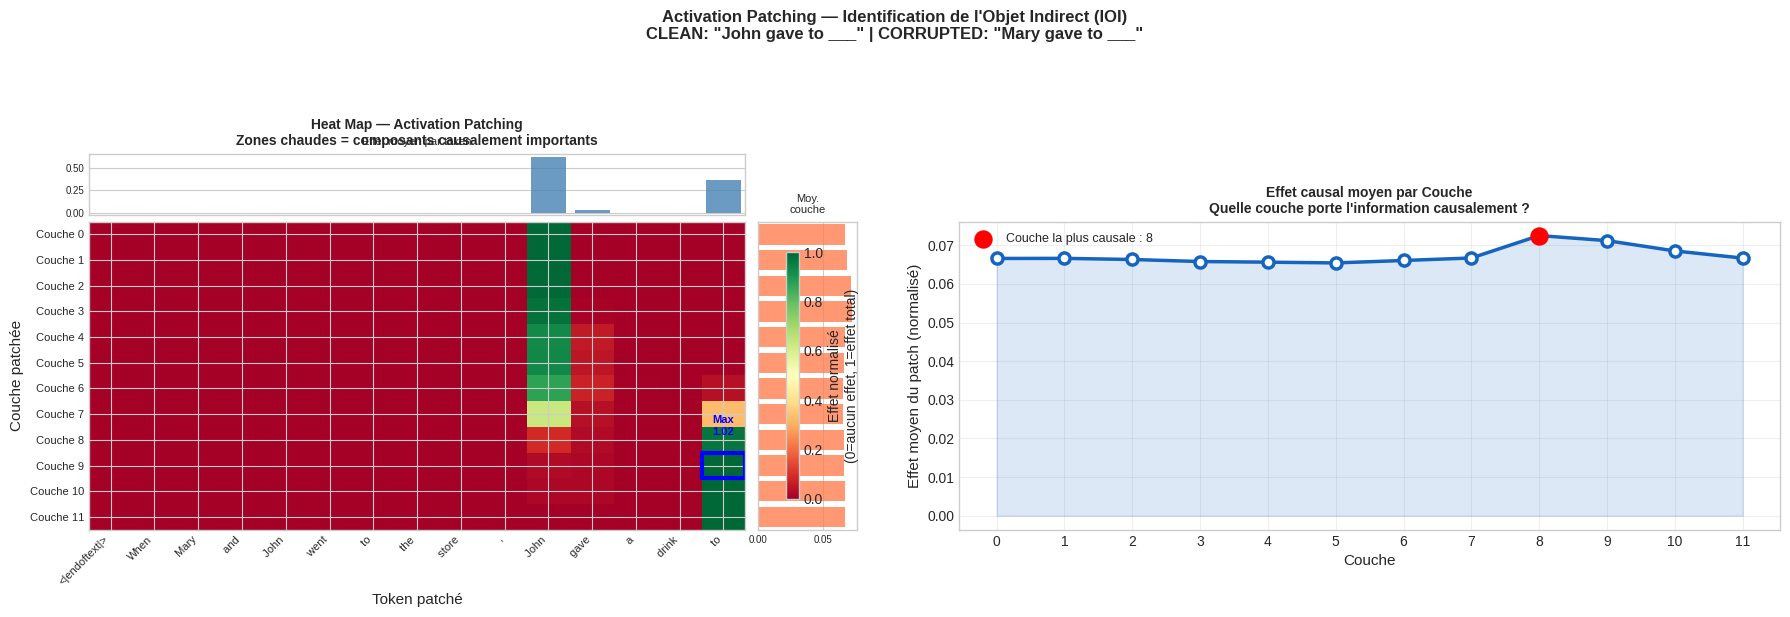


LECTURE DE LA HEAT MAP

Zone VERTE (effet fort = proche de 1) :
  → Patcher ce composant suffit à restaurer la bonne prédiction
  → Ce composant EST causalement responsable

Zone ROUGE (effet nul = proche de 0) :
  → Patcher ce composant ne change rien
  → Ce composant n'est PAS responsable de cette prédiction

Couche la plus causalement importante : Couche 8

DIFFÉRENCE AVEC CLASSIFIER PROBE :
  Probe    → CORRÉLATION  : "l'info est là"
  Patching → CAUSALITÉ    : "ce composant L'UTILISE vraiment"


In [18]:
# ─────────────────────────────────────────────────────────────────
# Visualisation de la Heat Map — Activation Patching
# ─────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# ─── Heat Map principale ───
im = axes[0].imshow(
    patch_results,
    cmap='RdYlGn',
    aspect='auto',
    vmin=0, vmax=1,
    interpolation='nearest'
)
plt.colorbar(im, ax=axes[0], label='Effet normalisé\n(0=aucun effet, 1=effet total)', shrink=0.8)

axes[0].set_xticks(range(n_tokens))
axes[0].set_xticklabels(token_labels, rotation=45, ha='right', fontsize=8)
axes[0].set_yticks(range(n_layers))
axes[0].set_yticklabels([f'Couche {i}' for i in range(n_layers)], fontsize=8)
axes[0].set_xlabel('Token patché', fontsize=11)
axes[0].set_ylabel('Couche patchée', fontsize=11)
axes[0].set_title(
    'Heat Map — Activation Patching\n'
    'Zones chaudes = composants causalement importants',
    fontsize=10, fontweight='bold'
)

# Annoter les zones chaudes
max_idx = np.unravel_index(patch_results.argmax(), patch_results.shape)
axes[0].add_patch(plt.Rectangle(
    (max_idx[1] - 0.5, max_idx[0] - 0.5), 1, 1,
    fill=False, edgecolor='blue', linewidth=3
))
axes[0].text(max_idx[1], max_idx[0] - 1.2, f'Max\n{patch_results[max_idx]:.2f}',
             ha='center', fontsize=8, color='blue', fontweight='bold')

# ─── Effet moyen par couche et par token ───
layer_effects = patch_results.mean(axis=1)
token_effects = patch_results.mean(axis=0)

ax_top = axes[0].inset_axes([0, 1.02, 1, 0.2])
ax_top.bar(range(n_tokens), token_effects, color='steelblue', alpha=0.8)
ax_top.set_xlim(-0.5, n_tokens - 0.5)
ax_top.set_xticks([])
ax_top.set_title('Effet moyen par token', fontsize=8)
ax_top.tick_params(labelsize=7)

ax_right = axes[0].inset_axes([1.02, 0, 0.15, 1])
ax_right.barh(range(n_layers), layer_effects, color='coral', alpha=0.8)
ax_right.set_ylim(-0.5, n_layers - 0.5)
ax_right.set_yticks([])
ax_right.set_title('Moy.\ncouche', fontsize=8)
ax_right.tick_params(labelsize=7)

# ─── Graphe 2 : Effet par couche (agrégé) ───
axes[1].plot(range(n_layers), layer_effects, 'o-', color='#1565C0', linewidth=2.5,
             markersize=8, markerfacecolor='white', markeredgewidth=2.5)
axes[1].fill_between(range(n_layers), layer_effects, alpha=0.15, color='#1565C0')

best_layer_patch = layer_effects.argmax()
axes[1].scatter([best_layer_patch], [layer_effects[best_layer_patch]],
                color='red', s=150, zorder=5, label=f'Couche la plus causale : {best_layer_patch}')

axes[1].set_xlabel('Couche', fontsize=11)
axes[1].set_ylabel('Effet moyen du patch (normalisé)', fontsize=11)
axes[1].set_title(
    'Effet causal moyen par Couche\n'
    'Quelle couche porte l\'information causalement ?',
    fontsize=10, fontweight='bold'
)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(range(n_layers))

plt.suptitle(
    'Activation Patching — Identification de l\'Objet Indirect (IOI)\n'
    'CLEAN: "John gave to ___" | CORRUPTED: "Mary gave to ___"',
    fontsize=12, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

print()
print('=' * 60)
print('LECTURE DE LA HEAT MAP')
print('=' * 60)
print()
print('Zone VERTE (effet fort = proche de 1) :')
print('  → Patcher ce composant suffit à restaurer la bonne prédiction')
print('  → Ce composant EST causalement responsable')
print()
print('Zone ROUGE (effet nul = proche de 0) :')
print('  → Patcher ce composant ne change rien')
print('  → Ce composant n\'est PAS responsable de cette prédiction')
print()
print(f'Couche la plus causalement importante : Couche {best_layer_patch}')
print()
print('DIFFÉRENCE AVEC CLASSIFIER PROBE :')
print('  Probe    → CORRÉLATION  : "l\'info est là"')
print('  Patching → CAUSALITÉ    : "ce composant L\'UTILISE vraiment"')

---
<a id='section-4'></a>
## Section 4 — Sparse Auto-Encoders (SAEs)

### 📌 Rappel du problème : la Polysémantie

Dans un LLM, un même neurone peut s'activer pour des concepts sans aucun rapport :

```
Neurone 847 de GPT-2 :
  s'active pour : "Paris", "chats", "inférence bayésienne", "chaussures"
  → Impossible à interpréter !

Raison : le réseau a trop de concepts à encoder avec trop peu de neurones
→ il superpose plusieurs concepts sur un même neurone (polysémantie)
```

### 💡 Solution : le Sparse Auto-Encoder

```
On projette les activations denses du LLM dans un espace
beaucoup plus grand mais CREUX (sparse) :

  LLM : 768 neurones (dense) → concepts mélangés
         ↓ SAE ↓
  SAE : 4096+ neurones (sparse) → chaque neurone ≈ 1 concept

Contrainte de sparsité : seulement 2-5 neurones actifs par token
→ le SAE est FORCÉ de trouver des représentations monosémantiques
```

### 🏗️ Architecture du SAE

```
Encodeur : x (768) → h (4096)  avec h = ReLU(W_enc × x + b_enc)
Décodeur : h (4096) → x̂ (768) avec x̂ = W_dec × h + b_dec

Perte : ||x - x̂||² + λ × ||h||₁
         ↑                  ↑
   reconstruction       pénalité L1
        fidèle          (force la sparsité)
```

In [18]:
# ─────────────────────────────────────────────────────────────────
# Sparse Auto-Encoder TopK
# ─────────────────────────────────────────────────────────────────

import torch.nn as nn
import torch.optim as optim

class SparseAutoEncoder(nn.Module):
    """
    SAE avec sparsité TopK garantie.

    À chaque forward, on garde exactement K neurones actifs
    par token — la sparsité est garantie par construction,
    indépendamment des données ou du lambda.

    Approche utilisée par Anthropic (Scaling Monosemanticity 2024).

    Architecture :
    ─────────────────────────────────────────────────────────
    Encodeur : x (768) → h_pre (6144) via W_enc
               → ReLU
               → TopK : garder les K plus grandes valeurs

    Décodeur : h (6144) → x̂ (768) via W_dec

    Perte    : MSE(x, x̂) + λ × L1(h)
                ↑              ↑
           reconstruction   régularisation
              fidèle         auxiliaire légère
    """

    def __init__(self, d_input, d_hidden, k=64, sparsity_coeff=0.01):
        super().__init__()

        self.d_input        = d_input
        self.d_hidden       = d_hidden
        self.k              = k
        self.sparsity_coeff = sparsity_coeff

        # Biais pré-encodeur : centre les activations avant projection
        self.b_pre = nn.Parameter(torch.zeros(d_input))

        # Encodeur
        self.W_enc = nn.Parameter(
            nn.init.kaiming_uniform_(torch.empty(d_input, d_hidden))
        )
        self.b_enc = nn.Parameter(torch.zeros(d_hidden))

        # Décodeur
        self.W_dec = nn.Parameter(
            nn.init.kaiming_uniform_(torch.empty(d_hidden, d_input))
        )
        self.b_dec = nn.Parameter(torch.zeros(d_input))

        # Normaliser les colonnes du décodeur dès l'init
        self._normalize_decoder()

    def _normalize_decoder(self):
        """
        Normalise chaque ligne de W_dec à norme 1.
        Empêche le décodeur de tricher en ayant des normes
        très grandes (ce qui diminuerait artificiellement h).
        """
        with torch.no_grad():
            norms = self.W_dec.norm(dim=1, keepdim=True)
            self.W_dec.data /= norms.clamp(min=1e-8)

    def encode(self, x):
        """
        Projection + ReLU + TopK.
        Retourne un vecteur sparse avec exactement K valeurs non-nulles.
        """
        # Centrage pré-encodeur
        x_c   = x - self.b_pre

        # Projection linéaire
        h_pre = x_c @ self.W_enc + self.b_enc   # (batch, d_hidden)

        # ReLU
        h_relu = torch.relu(h_pre)

        # TopK : garder exactement les K plus grandes valeurs
        # → tout le reste mis à zéro
        topk_vals, topk_idx = torch.topk(h_relu, k=self.k, dim=-1)
        h_sparse = torch.zeros_like(h_relu)
        h_sparse.scatter_(-1, topk_idx, topk_vals)

        return h_sparse

    def decode(self, h):
        """Reconstruction depuis la représentation sparse."""
        return h @ self.W_dec + self.b_dec

    def forward(self, x):
        h     = self.encode(x)
        x_hat = self.decode(h)

        # Perte de reconstruction (MSE)
        recon_loss = ((x - x_hat) ** 2).mean()

        # L1 auxiliaire très faible (TopK fait déjà la sparsité)
        # Sert à pénaliser les grandes valeurs parmi les K actifs
        sparse_loss = self.sparsity_coeff * h.abs().mean()

        total_loss = recon_loss + sparse_loss

        return x_hat, h, {
            'recon':  recon_loss.item(),
            'sparse': sparse_loss.item(),
            'total':  total_loss.item()
        }


# ─── Configuration ────────────────────────────────────────────────
D_INPUT  = model.cfg.d_model   # 768
D_HIDDEN = 8 * D_INPUT          # 6144  (expansion ×8)
K        = 64                   # 64/6144 = 1.04% actifs
LAMBDA   = 0.01                 # L1 auxiliaire très faible

sae = SparseAutoEncoder(D_INPUT, D_HIDDEN, k=K, sparsity_coeff=LAMBDA)

true_sparsity_pct = K / D_HIDDEN * 100

print('✅ SAE TopK créé')
print(f'   d_input            : {D_INPUT}')
print(f'   d_hidden           : {D_HIDDEN}  (×{D_HIDDEN // D_INPUT})')
print(f'   K (actifs/token)   : {K}  ({true_sparsity_pct:.2f}% garanti)')
print(f'   λ L1 auxiliaire    : {LAMBDA}')
print(f'   Paramètres totaux  : {sum(p.numel() for p in sae.parameters()):,}')

✅ SAE TopK créé
   d_input            : 768
   d_hidden           : 6144  (×8)
   K (actifs/token)   : 64  (1.04% garanti)
   λ L1 auxiliaire    : 0.01
   Paramètres totaux  : 9,444,864


In [17]:
# ─────────────────────────────────────────────────────────────────
# Collecte des activations — version augmentée avec Wikipedia
# ─────────────────────────────────────────────────────────────────

print('Collecte des activations de GPT-2 pour entraîner le SAE...')
print(f'On va sonder la couche {SAE_LAYER} (milieu du réseau).')
print()

SAE_LAYER = 6

# Chargement Wikipedia
try:
    from datasets import load_dataset
    print('Chargement WikiText-2...')
    dataset = load_dataset('Salesforce/wikitext', 'wikitext-2-raw-v1', split='train')
    texts_for_sae = [
        row['text'].strip() for row in dataset
        if len(row['text'].strip()) > 60
    ][:300]
    print(f'✅ {len(texts_for_sae)} phrases Wikipedia chargées')

except Exception as e:
    print(f'⚠️ datasets non disponible ({e}), fallback sur phrases manuelles')
    texts_for_sae = [
        'Paris is the capital of France and a beautiful city.',
        'London is located in the United Kingdom near the Thames.',
        'The Eiffel Tower stands in the heart of Paris, France.',
        'Berlin is the capital city of Germany in Europe.',
        'Tokyo is a huge modern city in Japan with millions.',
        'Rome was the center of the ancient Roman Empire.',
        'Madrid is the largest city in Spain and its capital.',
        'Beijing is the political center of modern China.',
        'Cairo sits on the banks of the Nile river in Egypt.',
        'Sydney is the largest city in Australia by population.',
        'Neural networks learn by adjusting weights through backpropagation.',
        'The transformer architecture uses attention mechanisms for sequences.',
        'Quantum mechanics describes the behavior of particles at small scales.',
        'Einstein developed the theory of general relativity in the early century.',
        'DNA contains the genetic information required for all living organisms.',
        'The immune system protects the body against diseases and infections.',
        'Photosynthesis converts sunlight into chemical energy in plants.',
        'Black holes are regions of space where gravity is extremely strong.',
        'The periodic table organizes chemical elements by atomic number.',
        'Neurons transmit electrical signals throughout the nervous system.',
        'Shakespeare wrote many famous plays including Hamlet and Macbeth.',
        'The novel tells the story of a young man traveling across Europe.',
        'Poetry uses rhythm and metaphor to express deep human emotions.',
        'The author described the landscape with vivid and colorful language.',
        'Dickens wrote about poverty and social injustice in Victorian England.',
        'The story follows a detective solving a mysterious crime in London.',
        'The restaurant serves delicious pasta with fresh tomato sauce.',
        'Coffee is one of the most popular beverages in the entire world.',
        'Bread is baked from flour water and yeast in an oven.',
        'Wine is produced by fermenting crushed grapes over several weeks.',
        'Sushi is a traditional Japanese dish made with vinegared rice.',
        'The football team won the championship after a difficult season.',
        'Swimming is an excellent exercise for the whole human body.',
        'The marathon runner trained for months before the big race.',
        'Basketball requires speed agility and precise shooting skills.',
        'The French Revolution began in 1789 and changed European politics.',
        'World War II ended in 1945 after years of conflict worldwide.',
        'Ancient Egypt built the pyramids as tombs for their kings.',
        'The Roman Empire controlled most of Europe for several centuries.',
        'The Industrial Revolution transformed manufacturing in the nineteenth century.',
        'The internet has connected billions of people around the world.',
        'Artificial intelligence is transforming many industries and jobs.',
        'The smartphone became an essential tool in modern everyday life.',
        'Machine learning models are trained on large amounts of data.',
        'The computer processor executes millions of instructions per second.',
        'Programming languages allow humans to communicate with computers.',
        'Satellites orbit the Earth and enable global communication networks.',
        'Electric vehicles are becoming more common as battery technology improves.',
        'Vaccines have eradicated many dangerous diseases over the past century.',
        'The heart pumps blood through the circulatory system continuously.',
        'Antibiotics are used to treat bacterial infections in patients.',
        'Surgery requires precise instruments and a sterile environment.',
    ]

# ─── Collecte ─────────────────────────────────────────────────────
collected_activations = []
collected_tokens_str  = []
collected_tokens_ctx  = []

with torch.no_grad():
    for text in tqdm(texts_for_sae, desc='Extraction activations'):
        tokens     = model.to_tokens(text)
        token_strs = model.to_str_tokens(text)
        _, cache   = model.run_with_cache(tokens)
        acts       = cache[f'blocks.{SAE_LAYER}.hook_resid_post'][0]

        for i, (act, tok_str) in enumerate(zip(acts, token_strs)):
            collected_activations.append(act.cpu())
            collected_tokens_str.append(tok_str)
            collected_tokens_ctx.append({
                'token':    tok_str,
                'sentence': text,
                'position': i
            })

activation_dataset = torch.stack(collected_activations)

# ─── Normalisation mean + std ─────────────────────────────────────
# Division par std indispensable : réduit la magnitude des vecteurs
# et rend la MSE comparable entre dimensions
act_mean_saved = activation_dataset.mean(dim=0, keepdim=True)
act_std_saved  = activation_dataset.std(dim=0,  keepdim=True).clamp(min=1e-8)

activation_dataset_norm = (activation_dataset - act_mean_saved) / act_std_saved

# Sauvegarde pour dénormalisation ultérieure (analyse des features)
print(f'✅ {len(collected_activations)} vecteurs collectés')
print(f'   Shape  : {activation_dataset_norm.shape}')
print(f'   Mean   : {activation_dataset_norm.mean().item():.4f}  (doit ≈ 0)')
print(f'   Std    : {activation_dataset_norm.std().item():.4f}   (doit ≈ 1)')
print(f'   Min    : {activation_dataset_norm.min().item():.4f}')
print(f'   Max    : {activation_dataset_norm.max().item():.4f}')
print()
print('✅ act_mean_saved et act_std_saved sauvegardés pour dénormalisation')

Collecte des activations de GPT-2 pour entraîner le SAE...
On va sonder la couche 6 (milieu du réseau).

Chargement WikiText-2...
✅ 300 phrases Wikipedia chargées


Extraction activations: 100%|██████████| 300/300 [00:18<00:00, 16.28it/s]


✅ 45435 vecteurs collectés
   Shape  : torch.Size([45435, 768])
   Mean   : -0.0000  (doit ≈ 0)
   Std    : 1.0000   (doit ≈ 1)
   Min    : -11.5238
   Max    : 12.2653

✅ act_mean_saved et act_std_saved sauvegardés pour dénormalisation


Device : cuda
ENTRAÎNEMENT DU SAE TopK — Couche 6 de GPT-2
  Exemples           : 45435
  Batch size         : 512
  Epochs             : 200
  K (actifs/token)   : 64  (1.04% garanti)
  Lambda L1 aux      : 0.01
  Expansion          : 768 → 6144 (×8)
  Batchs/epoch       : 88

  Epoch  10/200 | Loss : 0.2083 | Recon : 0.2081 | Sparse L1 : 0.0002 | LR : 3.00e-04 | Actifs : 1.04%  (64/6144)
  Epoch  20/200 | Loss : 0.1461 | Recon : 0.1459 | Sparse L1 : 0.0002 | LR : 3.00e-04 | Actifs : 1.04%  (64/6144)
  Epoch  30/200 | Loss : 0.1224 | Recon : 0.1222 | Sparse L1 : 0.0002 | LR : 3.00e-04 | Actifs : 1.04%  (64/6144)
  Epoch  40/200 | Loss : 0.1110 | Recon : 0.1108 | Sparse L1 : 0.0002 | LR : 3.00e-04 | Actifs : 1.04%  (64/6144)
  Epoch  50/200 | Loss : 0.1045 | Recon : 0.1043 | Sparse L1 : 0.0002 | LR : 3.00e-04 | Actifs : 1.04%  (64/6144)
  Epoch  60/200 | Loss : 0.1003 | Recon : 0.1001 | Sparse L1 : 0.0002 | LR : 3.00e-04 | Actifs : 1.04%  (64/6144)
  Epoch  70/200 | Loss : 0.0973 | Rec

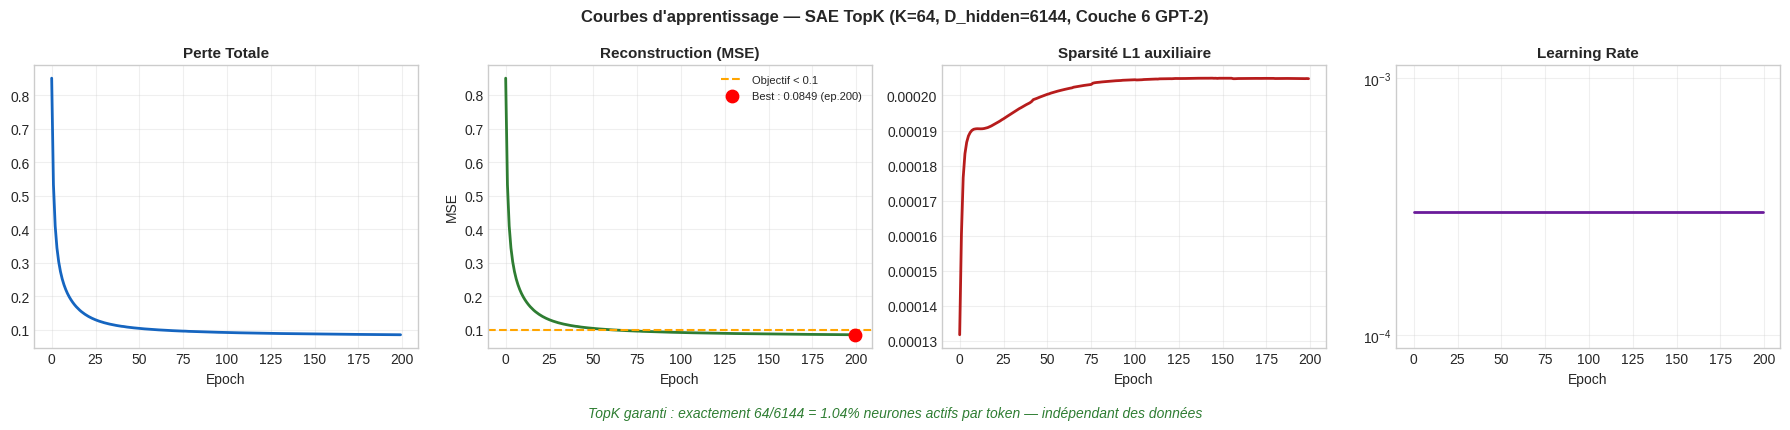

In [20]:
# ─────────────────────────────────────────────────────────────────
# Entraînement du SAE TopK
# ─────────────────────────────────────────────────────────────────

torch.set_grad_enabled(True)

# ─── Device ───────────────────────────────────────────────────────
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {device}')

# ─── Hyperparamètres ──────────────────────────────────────────────
BATCH_SIZE = 512
N_EPOCHS   = 200
N_SAMPLES  = len(activation_dataset_norm)

# ─── Données et modèle sur device ─────────────────────────────────
activation_dataset_gpu = activation_dataset_norm.to(device)
sae = sae.to(device)

# ─── Optimiseur ───────────────────────────────────────────────────
optimizer = optim.Adam(sae.parameters(), lr=3e-4, weight_decay=1e-6)

# ReduceLROnPlateau : baisse lr seulement si stagnation
# → pas de spike artificiel contrairement à CosineAnnealingLR
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode      = 'min',
    factor    = 0.5,
    patience  = 15,
    min_lr    = 1e-6,

)

# ─── DataLoader ───────────────────────────────────────────────────
from torch.utils.data import DataLoader, TensorDataset

dataloader = DataLoader(
    TensorDataset(activation_dataset_gpu),
    batch_size = BATCH_SIZE,
    shuffle    = True,
    pin_memory = False,   # données déjà sur GPU
)

print('=' * 60)
print(f'ENTRAÎNEMENT DU SAE TopK — Couche {SAE_LAYER} de GPT-2')
print('=' * 60)
print(f'  Exemples           : {N_SAMPLES}')
print(f'  Batch size         : {BATCH_SIZE}')
print(f'  Epochs             : {N_EPOCHS}')
print(f'  K (actifs/token)   : {K}  ({true_sparsity_pct:.2f}% garanti)')
print(f'  Lambda L1 aux      : {LAMBDA}')
print(f'  Expansion          : {D_INPUT} → {D_HIDDEN} (×{D_HIDDEN // D_INPUT})')
print(f'  Batchs/epoch       : {N_SAMPLES // BATCH_SIZE}')
print()

loss_history     = []
recon_history    = []
sparsity_history = []
lr_history       = []

best_recon = float('inf')
best_epoch = 0

for epoch in range(N_EPOCHS):

    epoch_losses = []
    epoch_recon  = []
    epoch_sparse = []

    for (batch,) in dataloader:

        optimizer.zero_grad()

        x_hat, h, _ = sae(batch)

        # Recalcul explicite pour avoir le graphe de calcul
        recon  = ((batch - x_hat) ** 2).mean()
        sparse = LAMBDA * h.abs().mean()
        loss   = recon + sparse

        loss.backward()

        # Gradient clipping : évite les explosions de gradient
        torch.nn.utils.clip_grad_norm_(sae.parameters(), max_norm=1.0)

        optimizer.step()

        # Renormaliser le décodeur après chaque step
        sae._normalize_decoder()

        epoch_losses.append(loss.item())
        epoch_recon.append(recon.item())
        epoch_sparse.append(sparse.item())

    avg_loss   = np.mean(epoch_losses)
    avg_recon  = np.mean(epoch_recon)
    avg_sparse = np.mean(epoch_sparse)
    current_lr = optimizer.param_groups[0]['lr']

    loss_history.append(avg_loss)
    recon_history.append(avg_recon)
    sparsity_history.append(avg_sparse)
    lr_history.append(current_lr)

    # Scheduler basé sur la reconstruction
    scheduler.step(avg_recon)

    # Sauvegarder le meilleur modèle
    if avg_recon < best_recon:
        best_recon = avg_recon
        best_epoch = epoch + 1

    if (epoch + 1) % 10 == 0:
        print(f'  Epoch {epoch+1:3d}/{N_EPOCHS} | '
              f'Loss : {avg_loss:.4f} | '
              f'Recon : {avg_recon:.4f} | '
              f'Sparse L1 : {avg_sparse:.4f} | '
              f'LR : {current_lr:.2e} | '
              f'Actifs : {true_sparsity_pct:.2f}%  ({K}/{D_HIDDEN})')

torch.set_grad_enabled(False)

print()
print('✅ Entraînement terminé')
print(f'   Sparsité garantie par TopK  : {true_sparsity_pct:.2f}%  ✅')
print(f'   Meilleure reconstruction    : {best_recon:.4f}  (epoch {best_epoch})')
print(f'   Reconstruction finale       : {recon_history[-1]:.4f}')
print(f'   Loss finale                 : {loss_history[-1]:.4f}')

# ─── Interprétation de la reconstruction ──────────────────────────
if recon_history[-1] < 0.1:
    print('   Qualité reconstruction      : 🟢 Excellente  (< 0.1)')
elif recon_history[-1] < 0.3:
    print('   Qualité reconstruction      : 🟡 Bonne       (< 0.3)')
else:
    print('   Qualité reconstruction      : 🔴 À améliorer (> 0.3)')
    print('   → Essayer K=128 ou D_HIDDEN=×16')

# ─── Courbes d'apprentissage ──────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

axes[0].plot(loss_history,     color='#1565C0', linewidth=2)
axes[0].set_title('Perte Totale',           fontsize=11, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].grid(True, alpha=0.3)

axes[1].plot(recon_history,    color='#2E7D32', linewidth=2)
axes[1].axhline(y=0.1, color='orange', linestyle='--', linewidth=1.5, label='Objectif < 0.1')
axes[1].scatter([best_epoch - 1], [best_recon], color='red', s=80, zorder=5,
                label=f'Best : {best_recon:.4f} (ep.{best_epoch})')
axes[1].set_title('Reconstruction (MSE)',   fontsize=11, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

axes[2].plot(sparsity_history, color='#B71C1C', linewidth=2)
axes[2].set_title('Sparsité L1 auxiliaire', fontsize=11, fontweight='bold')
axes[2].set_xlabel('Epoch')
axes[2].grid(True, alpha=0.3)

axes[3].plot(lr_history,       color='#6A1B9A', linewidth=2)
axes[3].set_title('Learning Rate',          fontsize=11, fontweight='bold')
axes[3].set_xlabel('Epoch')
axes[3].set_yscale('log')
axes[3].grid(True, alpha=0.3)

fig.text(
    0.5, -0.04,
    f'TopK garanti : exactement {K}/{D_HIDDEN} = {true_sparsity_pct:.2f}% '
    f'neurones actifs par token — indépendant des données',
    ha='center', fontsize=10, color='#2E7D32', fontstyle='italic'
)

plt.suptitle(
    f"Courbes d'apprentissage — SAE TopK (K={K}, D_hidden={D_HIDDEN}, "
    f"Couche {SAE_LAYER} GPT-2)",
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()

ANALYSE DES FEATURES SAE — Couche 6 de GPT-2

Principe : pour chaque neurone SAE, les tokens qui
l'activent le plus = le "concept" de ce neurone.

Shape des activations SAE : (45435, 6144)

Statistiques de sparsité :
  Neurones actifs par token (moy)  : 63.7 / 6144
  Neurones actifs par token (std)  : 3.7
  Neurones morts   (jamais actifs) : 24  (0.4%)
  Neurones rares   (≤ 5 tokens)    : 0  (0.0%)
  Neurones communs (> 50 tokens)   : 5998  (97.6%)

Top 5 features SAE les plus actives :

  Feature #4260  (active sur 17776 tokens)
  Token           Activation   Contexte
  --------------- ----------   ----------------------------------------
  " interior"          9.365   The interior walls and ceiling of the hall were richly ...
  " mask"              9.217   The plain maskray generally hunts at the surface of the...
  " mask"              9.217   The plain maskray inhabits the continental shelf of nor...
  " mask"              9.217   The plain maskray or brown stingray ( Neotrygon ann

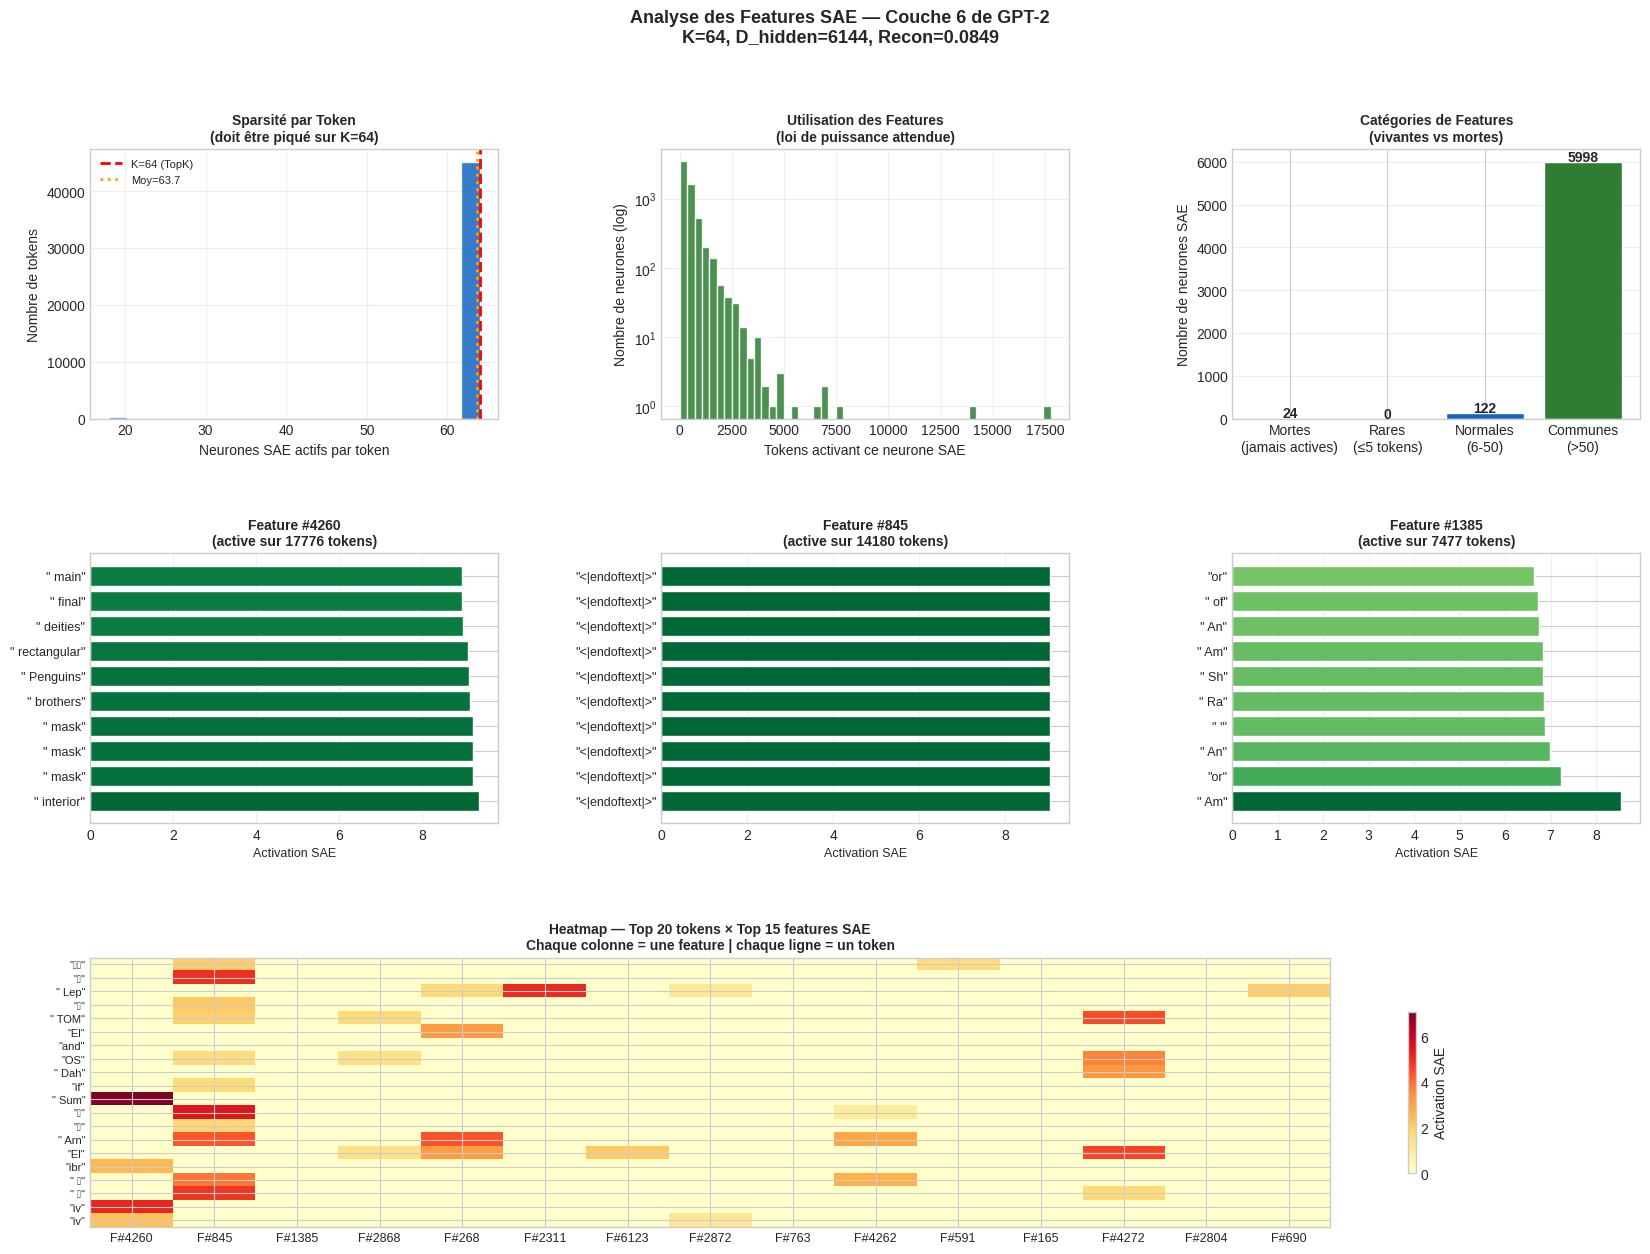


COMMENT INTERPRÉTER UNE FEATURE SAE

Si les top tokens partagent un thème commun :
  → tokens géographiques (Paris, London, Berlin)
    = feature "noms de villes"

  → tokens scientifiques (quantum, neural, DNA)
    = feature "vocabulaire scientifique"

  → tokens de ponctuation (., ,, !)
    = feature "fin de phrase"

C'est la différence avec un neurone LLM brut :
  Neurone brut → polysémantique (concepts mélangés)
  Neurone SAE  → tend vers la monosémantie (1 concept)


In [21]:
# ─────────────────────────────────────────────────────────────────
# Analyse des Features SAE
# ─────────────────────────────────────────────────────────────────

print('=' * 60)
print('ANALYSE DES FEATURES SAE — Couche 6 de GPT-2')
print('=' * 60)
print()
print('Principe : pour chaque neurone SAE, les tokens qui')
print('l\'activent le plus = le "concept" de ce neurone.')
print()

# ─── Passer tout le dataset dans le SAE ──────────────────────────
sae.eval()
with torch.no_grad():
    _, sae_activations, _ = sae(activation_dataset_gpu)
    sae_activations = sae_activations.cpu()

sae_acts_np = sae_activations.numpy()  # (n_tokens, 6144)

print(f'Shape des activations SAE : {sae_acts_np.shape}')
print()

# ─── Statistiques globales ────────────────────────────────────────
active_per_token   = (sae_acts_np > 0).sum(axis=1)   # neurones actifs par token
active_per_feature = (sae_acts_np > 0).sum(axis=0)   # tokens activant chaque feature

n_dead = (active_per_feature == 0).sum()
n_rare = ((active_per_feature > 0) & (active_per_feature <= 5)).sum()
n_common = (active_per_feature > 50).sum()

print('Statistiques de sparsité :')
print(f'  Neurones actifs par token (moy)  : {active_per_token.mean():.1f} / {D_HIDDEN}')
print(f'  Neurones actifs par token (std)  : {active_per_token.std():.1f}')
print(f'  Neurones morts   (jamais actifs) : {n_dead}  ({n_dead/D_HIDDEN*100:.1f}%)')
print(f'  Neurones rares   (≤ 5 tokens)    : {n_rare}  ({n_rare/D_HIDDEN*100:.1f}%)')
print(f'  Neurones communs (> 50 tokens)   : {n_common}  ({n_common/D_HIDDEN*100:.1f}%)')
print()

# ─── Fonction d'interprétation ────────────────────────────────────
def get_top_tokens_for_feature(feature_idx, top_k=10):
    """
    Retourne les top_k tokens qui activent le plus
    le neurone SAE numéro feature_idx, avec leur contexte.
    """
    acts_for_feature = sae_acts_np[:, feature_idx]
    top_indices = acts_for_feature.argsort()[::-1][:top_k]
    results = []
    for idx in top_indices:
        val = acts_for_feature[idx]
        if val > 0:
            results.append({
                'token'    : collected_tokens_str[idx],
                'activation': val,
                'sentence' : collected_tokens_ctx[idx]['sentence'][:80],
                'position' : collected_tokens_ctx[idx]['position'],
            })
    return results


def interpret_feature(feature_idx, top_k=8):
    """Affiche une interprétation lisible d'une feature SAE."""
    top = get_top_tokens_for_feature(feature_idx, top_k)
    print(f'  Feature #{feature_idx:4d}  '
          f'(active sur {active_per_feature[feature_idx]} tokens)')
    print(f'  {"Token":<15} {"Activation":>10}   Contexte')
    print(f'  {"-"*15} {"-"*10}   {"-"*40}')
    for item in top:
        tok  = f'"{item["token"]}"'
        act  = f'{item["activation"]:.3f}'
        ctx  = item["sentence"][:55] + '...'
        print(f'  {tok:<15} {act:>10}   {ctx}')
    print()


# ─── Top features les plus actives ───────────────────────────────
most_active_features = active_per_feature.argsort()[::-1][:20]

print('Top 5 features SAE les plus actives :')
print()
for feat_idx in most_active_features[:5]:
    interpret_feature(feat_idx)

# ─────────────────────────────────────────────────────────────────
# Visualisation complète
# ─────────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(20, 14))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.4)

# ─── 1. Distribution sparsité par token ──────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(active_per_token, bins=20, color='#1565C0',
         edgecolor='white', alpha=0.85)
ax1.axvline(K, color='red', linestyle='--', linewidth=2,
            label=f'K={K} (TopK)')
ax1.axvline(active_per_token.mean(), color='orange', linestyle=':',
            linewidth=2, label=f'Moy={active_per_token.mean():.1f}')
ax1.set_xlabel('Neurones SAE actifs par token', fontsize=10)
ax1.set_ylabel('Nombre de tokens', fontsize=10)
ax1.set_title('Sparsité par Token\n(doit être piqué sur K=64)',
              fontsize=10, fontweight='bold')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# ─── 2. Distribution utilisation des features (loi de puissance) ─
ax2 = fig.add_subplot(gs[0, 1])
nonzero_counts = active_per_feature[active_per_feature > 0]
ax2.hist(nonzero_counts, bins=50, color='#2E7D32',
         edgecolor='white', alpha=0.85, log=True)
ax2.set_xlabel('Tokens activant ce neurone SAE', fontsize=10)
ax2.set_ylabel('Nombre de neurones (log)', fontsize=10)
ax2.set_title('Utilisation des Features\n(loi de puissance attendue)',
              fontsize=10, fontweight='bold')
ax2.grid(True, alpha=0.3)

# ─── 3. Features mortes vs vivantes ──────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
categories = ['Mortes\n(jamais actives)', 'Rares\n(≤5 tokens)',
              'Normales\n(6-50)', 'Communes\n(>50)']
n_normal = D_HIDDEN - n_dead - n_rare - n_common
counts   = [n_dead, n_rare, n_normal, n_common]
colors3  = ['#B71C1C', '#F57F17', '#1565C0', '#2E7D32']
bars3 = ax3.bar(categories, counts, color=colors3, edgecolor='white')
for bar, cnt in zip(bars3, counts):
    ax3.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 20,
             str(cnt), ha='center', fontsize=10, fontweight='bold')
ax3.set_ylabel('Nombre de neurones SAE', fontsize=10)
ax3.set_title('Catégories de Features\n(vivantes vs mortes)',
              fontsize=10, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')

# ─── 4-6. Top tokens des 3 meilleures features ───────────────────
for i, feat_idx in enumerate(most_active_features[:3]):
    ax = fig.add_subplot(gs[1, i])
    top_items = get_top_tokens_for_feature(feat_idx, top_k=10)
    tok_names = [f'"{item["token"]}"' for item in top_items]
    tok_vals  = [item['activation'] for item in top_items]

    if tok_vals:
        cmap_vals = np.array(tok_vals) / max(tok_vals)
        bar_colors = plt.cm.RdYlGn(cmap_vals)
        ax.barh(range(len(tok_names)), tok_vals,
                color=bar_colors, edgecolor='white')
        ax.set_yticks(range(len(tok_names)))
        ax.set_yticklabels(tok_names, fontsize=9)
        ax.set_xlabel('Activation SAE', fontsize=9)
        ax.set_title(
            f'Feature #{feat_idx}\n'
            f'(active sur {active_per_feature[feat_idx]} tokens)',
            fontsize=10, fontweight='bold'
        )
        ax.grid(True, alpha=0.3, axis='x')
    else:
        ax.text(0.5, 0.5, 'Aucune activation', ha='center',
                va='center', fontsize=11)

# ─── 7. Heatmap top features × top tokens ────────────────────────
ax7 = fig.add_subplot(gs[2, :])
top_feat_idx = most_active_features[:15]
top_tok_idx  = sae_acts_np.sum(axis=1).argsort()[::-1][:20]

heatmap_data = sae_acts_np[np.ix_(top_tok_idx, top_feat_idx)]
tok_labels_h = [f'"{collected_tokens_str[i]}"' for i in top_tok_idx]
feat_labels_h = [f'F#{i}' for i in top_feat_idx]

im = ax7.imshow(heatmap_data, cmap='YlOrRd', aspect='auto')
plt.colorbar(im, ax=ax7, shrink=0.6, label='Activation SAE')
ax7.set_xticks(range(len(top_feat_idx)))
ax7.set_xticklabels(feat_labels_h, fontsize=9)
ax7.set_yticks(range(len(top_tok_idx)))
ax7.set_yticklabels(tok_labels_h, fontsize=8)
ax7.set_title(
    'Heatmap — Top 20 tokens × Top 15 features SAE\n'
    'Chaque colonne = une feature | chaque ligne = un token',
    fontsize=10, fontweight='bold'
)

plt.suptitle(
    f'Analyse des Features SAE — Couche {SAE_LAYER} de GPT-2\n'
    f'K={K}, D_hidden={D_HIDDEN}, Recon={recon_history[-1]:.4f}',
    fontsize=13, fontweight='bold'
)
plt.show()

print()
print('=' * 60)
print('COMMENT INTERPRÉTER UNE FEATURE SAE')
print('=' * 60)
print()
print('Si les top tokens partagent un thème commun :')
print('  → tokens géographiques (Paris, London, Berlin)')
print('    = feature "noms de villes"')
print()
print('  → tokens scientifiques (quantum, neural, DNA)')
print('    = feature "vocabulaire scientifique"')
print()
print('  → tokens de ponctuation (., ,, !)')
print('    = feature "fin de phrase"')
print()
print('C\'est la différence avec un neurone LLM brut :')
print('  Neurone brut → polysémantique (concepts mélangés)')
print('  Neurone SAE  → tend vers la monosémantie (1 concept)')